# Notebook 04 — Model B: ClinicalBERT Transformer
**Week 3**: Fine-tune Bio_ClinicalBERT for multi-label ICD-10 prediction with section-based truncation for long discharge notes.

In [1]:
# Install PyTorch with CUDA 12.4 (run ONCE in a regular terminal, not here):
# python -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
#
# Then install remaining deps:
# pip install -q transformers datasets accelerate pandas pyarrow numpy scikit-learn

In [2]:
# Running locally — no Drive mount needed

## 1. Config

In [5]:
import os, json, pickle, re
import numpy as np
import pandas as pd
import torch
from pathlib import Path

DATA_DIR  = '../datasets/processed'
MODEL_DIR = '../data/models/model_b'
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME    = 'emilyalsentzer/Bio_ClinicalBERT'
MAX_SEQ_LEN   = 512
LR            = 2e-5
EPOCHS        = 3
WARMUP_RATIO  = 0.1
SEED          = 42
USE_AMP       = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
GRAD_ACCUM = 1

if torch.cuda.is_available():
    print(f'✓ GPU: {torch.cuda.get_device_name(0)}')
    print(f'✓ CUDA: {torch.version.cuda}')
    print(f'✓ fp16: ENABLED')
else:
    print('⚠ No GPU detected — will be very slow!')

print(f'Device: {device}  |  Batch: {BATCH_SIZE}  |  Effective: {BATCH_SIZE * GRAD_ACCUM}')


✓ GPU: NVIDIA L4
✓ CUDA: 12.8
✓ fp16: ENABLED
Device: cuda  |  Batch: 32  |  Effective: 32


## 2. Load data & label binarizer

In [6]:
train_df = pd.read_parquet(f'{DATA_DIR}/cohort_train_clean.parquet')
val_df   = pd.read_parquet(f'{DATA_DIR}/cohort_val_clean.parquet')
test_df  = pd.read_parquet(f'{DATA_DIR}/cohort_test_clean.parquet')

with open(f'{DATA_DIR}/mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)
NUM_LABELS = len(vocab)

for df_ in [train_df, val_df, test_df]:
    df_['icd_codes'] = df_['icd_codes_str'].str.split('|')

Y_train = mlb.transform(train_df['icd_codes']).astype(np.float32)
Y_val   = mlb.transform(val_df['icd_codes']).astype(np.float32)
Y_test  = mlb.transform(test_df['icd_codes']).astype(np.float32)

print(f'Labels: {NUM_LABELS}  Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00160J2', '00160J6', '00163J4', '00163J6', '00164J6', '00520ZZ', '005C0ZZ', '005T0ZZ', '008Q0ZZ', '008Q4ZZ', '008X0ZZ', '009000Z', '00900ZZ', '009030Z', '00903ZZ', '00904ZZ', '00920ZZ', '009300Z', '00930ZX', '00930ZZ', '009330Z', '00933ZZ', '009400Z', '00940ZZ', '009430Z', '00943ZZ', '00944ZZ', '00950ZZ', '00953ZX', '009600Z', '00960ZZ', '009630Z', '00963ZX', '00963ZZ', '009640Z', '009700Z', '00970ZZ', '00973ZX', '00973ZZ', '009C0ZZ', '009T00Z', '009T0ZZ', '009T30Z', '009T3ZX', '009U00Z', '009U0ZX', '009U0ZZ', '009U30Z', '009U3ZX', '009U3ZZ', '009W00Z', '009W0ZZ', '009X3ZX', '009X3ZZ', '009Y30Z', '009Y3ZX', '009Y3ZZ', '00B00ZX', '00B00ZZ', '00B03ZX', '00B03ZZ', '00B04ZZ', '00B10ZX', '00B10ZZ', '00B13ZX', '00B14ZZ', '00B20ZX', '00B20ZZ', '00B23ZX', '00B24ZZ', '00B60ZX', '00B60ZZ', '00B70ZX', '00B70ZZ', '00B73ZX', '00B80ZX', '00B83ZX', '00B90ZX', '00B90ZZ', '00B93ZX', '00

Labels: 50  Train: 85081  Val: 18371  Test: 18852


/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00160J6', '00163J6', '00164J6', '00560ZZ', '008Q4ZZ', '009000Z', '00900ZZ', '00903ZZ', '00910ZX', '00910ZZ', '009300Z', '009400Z', '00940ZZ', '009430Z', '00943ZZ', '00944ZZ', '009600Z', '009630Z', '00963ZX', '009640Z', '00970ZZ', '009C3ZX', '009T30Z', '009U00Z', '009U0ZZ', '009U30Z', '009U3ZX', '009U3ZZ', '009Y30Z', '009Y3ZX', '009Y4ZZ', '00B00ZX', '00B00ZZ', '00B03ZX', '00B04ZX', '00B10ZZ', '00B13ZZ', '00B20ZX', '00B20ZZ', '00B23ZX', '00B60ZX', '00B60ZZ', '00B70ZX', '00B70ZZ', '00B73ZX', '00B83ZX', '00B90ZX', '00B93ZX', '00BC0ZX', '00BC0ZZ', '00BM0ZZ', '00BQ0ZZ', '00BT0ZX', '00BT0ZZ', '00BW0ZX', '00BW0ZZ', '00BX0ZX', '00BX0ZZ', '00BY0ZX', '00BY0ZZ', '00C00ZZ', '00C03ZZ', '00C10ZZ', '00C30ZZ', '00C40ZZ', '00C43ZZ', '00C70ZZ', '00CC0ZZ', '00CT0ZZ', '00CU0ZZ', '00CW0ZZ', '00CX0ZZ', '00CY0ZZ', '00D20ZZ', '00H00MZ', '00H032Z', '00H03MZ', '00HU03Z', '00HU0MZ', '00HU33Z', '00

## 3. Section-based text truncation (long-text strategy)
Priority order: Discharge Diagnoses → Hospital Course → Chief Complaint → beginning of note

In [7]:
# Section priority for clinical relevance
_SECTION_PATTERNS = [
    r'discharge diagnos[ei]s.*?(?=\n[A-Z][A-Z ]{3,}:|$)',
    r'discharge condition.*?(?=\n[A-Z][A-Z ]{3,}:|$)',
    r'hospital course.*?(?=\n[A-Z][A-Z ]{3,}:|$)',
    r'history of present illness.*?(?=\n[A-Z][A-Z ]{3,}:|$)',
    r'chief complaint.*?(?=\n[A-Z][A-Z ]{3,}:|$)',
]
_COMPILED = [re.compile(p, re.IGNORECASE | re.DOTALL) for p in _SECTION_PATTERNS]

def smart_truncate(text: str, max_chars: int = 2000) -> str:
    """Extract high-priority sections first, then fill up to max_chars."""
    segments = []
    total = 0
    for pat in _COMPILED:
        m = pat.search(text)
        if m:
            seg = m.group(0).strip()
            if total + len(seg) <= max_chars:
                segments.append(seg)
                total += len(seg)
    if total < max_chars:
        # Fill remainder from beginning of note
        segments.insert(0, text[:max_chars - total])
    return ' '.join(segments)[:max_chars]

# max_chars ≈ MAX_SEQ_LEN * ~4 chars/token
CHAR_LIMIT = MAX_SEQ_LEN * 4
for df_ in [train_df, val_df, test_df]:
    df_['model_text'] = df_['clean_text'].apply(lambda t: smart_truncate(t, CHAR_LIMIT))

print('Sample truncated text (first 400 chars):')
print(train_df['model_text'].iloc[0][:400])

Sample truncated text (first 400 chars):
name: . unit no: admission date: discharge date: date of birth: sex: f service: medicine allergies: demerol / latex attending: . major surgical or invasive procedure: : push enteroscopy and colonoscopy attach pertinent results: admission labs -------------------- 12:16am blood wbc-4.8 rbc-2.04 hgb-5.4 hct-18.3 mcv-90 mch-26.5 mchc-29.5 rdw-16.1 rdwsd-53.3 plt 02:24am blood ptt-29.8 12:16am blood g


## 4. Dataset & DataLoader

In [8]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ICDDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = labels   # np.ndarray (n, num_labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_SEQ_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_ds = ICDDataset(train_df['model_text'], Y_train)
val_ds   = ICDDataset(val_df['model_text'],   Y_val)
test_ds  = ICDDataset(test_df['model_text'],  Y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train batches: 2659  Val batches: 575


## 5. Model — BERT with sigmoid multi-label head

In [9]:
from transformers import AutoModel
import torch.nn as nn

class ICDClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        hidden_size  = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [CLS] token
        cls = self.dropout(cls)
        return self.head(cls)   # raw logits

model = ICDClassifier(MODEL_NAME, NUM_LABELS).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

BertModel loaded from: emilyalsentzer/Bio_ClinicalBERT
Trainable parameters: 108,348,722


## 6. Training loop

In [10]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score

total_steps   = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
criterion = nn.BCEWithLogitsLoss()
scaler    = torch.amp.GradScaler(device, enabled=USE_AMP and device == 'cuda')

def val_micro_f1(loader, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            with torch.amp.autocast(device, enabled=USE_AMP and device == 'cuda'):
                logits = model(ids, mask)
            probs  = torch.sigmoid(logits).cpu().float().numpy()
            all_preds.append(probs)
            all_labels.append(batch['labels'].numpy())
    P = np.vstack(all_preds)
    Y = np.vstack(all_labels)
    return f1_score(Y, (P >= threshold).astype(int), average='micro', zero_division=0), P, Y

best_val_f1   = 0.0
history       = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.amp.autocast(device, enabled=USE_AMP and device == 'cuda'):
            logits = model(ids, mask)
            loss   = criterion(logits, labels) / GRAD_ACCUM

        scaler.scale(loss).backward()
        total_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        # Progress logging
        if (step + 1) % 500 == 0:
            print(f'  Step {step+1}/{len(train_loader)}  loss={total_loss/(step+1):.4f}')

        # Mid-epoch checkpoint (safety against disconnects/crashes)
        if (step + 1) % 2000 == 0:
            torch.save({
                'epoch': epoch, 'step': step,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
            }, f'{MODEL_DIR}/checkpoint_e{epoch}_s{step+1}.pt')
            print(f'  → mid-epoch checkpoint saved')

    avg_loss = total_loss / len(train_loader)
    val_f1, P_val, Y_val_np = val_micro_f1(val_loader)
    history.append({'epoch': epoch, 'train_loss': avg_loss, 'val_micro_f1': val_f1})
    print(f'Epoch {epoch}/{EPOCHS}  loss={avg_loss:.4f}  val_micro_F1={val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), f'{MODEL_DIR}/best_model.pt')
        np.save(f'{MODEL_DIR}/P_val_best.npy',  P_val)
        np.save(f'{MODEL_DIR}/Y_val_best.npy',  Y_val_np)
        print('  → saved best checkpoint')

pd.DataFrame(history).to_csv(f'{MODEL_DIR}/training_history.csv', index=False)
print('Training complete. Best val micro-F1:', best_val_f1)

  Step 500/2659  loss=0.3954
  Step 1000/2659  loss=0.3436
  Step 1500/2659  loss=0.3172
  Step 2000/2659  loss=0.3003
  → mid-epoch checkpoint saved
  Step 2500/2659  loss=0.2889
Epoch 1/3  loss=0.2859  val_micro_F1=0.4113
  → saved best checkpoint
  Step 500/2659  loss=0.2348
  Step 1000/2659  loss=0.2333
  Step 1500/2659  loss=0.2328
  Step 2000/2659  loss=0.2321
  → mid-epoch checkpoint saved
  Step 2500/2659  loss=0.2312
Epoch 2/3  loss=0.2309  val_micro_F1=0.4626
  → saved best checkpoint
  Step 500/2659  loss=0.2231
  Step 1000/2659  loss=0.2229
  Step 1500/2659  loss=0.2223
  Step 2000/2659  loss=0.2216
  → mid-epoch checkpoint saved
  Step 2500/2659  loss=0.2212
Epoch 3/3  loss=0.2212  val_micro_F1=0.4681
  → saved best checkpoint
Training complete. Best val micro-F1: 0.4681215797455001


## 7. Threshold tuning & test evaluation

In [11]:
# Reload best checkpoint
model.load_state_dict(torch.load(f'{MODEL_DIR}/best_model.pt', map_location=device))

# Tune threshold on val
P_val_best = np.load(f'{MODEL_DIR}/P_val_best.npy')
Y_val_best = np.load(f'{MODEL_DIR}/Y_val_best.npy')

best_t, best_vf1 = 0.5, 0.0
for t in np.arange(0.05, 0.65, 0.025):
    vf1 = f1_score(Y_val_best, (P_val_best >= t).astype(int), average='micro', zero_division=0)
    if vf1 > best_vf1:
        best_vf1, best_t = vf1, t
print(f'Best threshold: {best_t:.3f}  val micro-F1: {best_vf1:.4f}')

# Test evaluation
from sklearn.metrics import precision_score, recall_score, average_precision_score, roc_auc_score

test_f1, P_test, Y_test_np = val_micro_f1(test_loader, threshold=best_t)
preds_test = (P_test >= best_t).astype(int)

mask = Y_test_np.sum(0) > 0
results = {
    'threshold'   : best_t,
    'micro_f1'    : f1_score(Y_test_np, preds_test, average='micro',  zero_division=0),
    'macro_f1'    : f1_score(Y_test_np, preds_test, average='macro',  zero_division=0),
    'micro_prec'  : precision_score(Y_test_np, preds_test, average='micro', zero_division=0),
    'micro_rec'   : recall_score(Y_test_np, preds_test, average='micro',    zero_division=0),
    'macro_auprc' : average_precision_score(Y_test_np[:, mask], P_test[:, mask], average='macro'),
    'micro_auroc' : roc_auc_score(Y_test_np[:, mask], P_test[:, mask], average='micro'),
}
for k, v in results.items():
    print(f'  {k:20s}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

with open(f'{MODEL_DIR}/test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

np.save(f'{MODEL_DIR}/P_test.npy', P_test)
np.save(f'{MODEL_DIR}/Y_test.npy', Y_test_np)
print('Test results & probabilities saved.')

Best threshold: 0.275  val micro-F1: 0.5301
  threshold           : 0.2750
  micro_f1            : 0.5242
  macro_f1            : 0.4429
  micro_prec          : 0.5247
  micro_rec           : 0.5237
  macro_auprc         : 0.4541
  micro_auroc         : 0.8686
Test results & probabilities saved.


## 8. Head vs. tail analysis

head (≥500)                n=   50  avg_F1=0.4429
torso (100-499)            n=    0  avg_F1=nan
tail (<100)                n=    0  avg_F1=nan


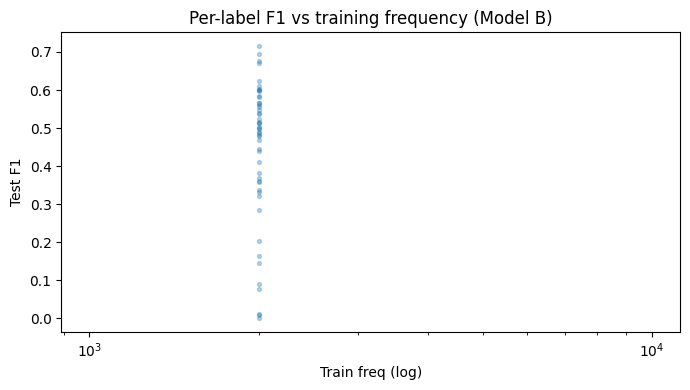

In [12]:
import matplotlib.pyplot as plt

Y_train_full = np.load(f'{DATA_DIR}/Y_train.npy')
per_label_freq = Y_train_full.sum(0)
per_label_f1   = f1_score(Y_test_np, preds_test, average=None, zero_division=0)

label_df = pd.DataFrame({'icd_code': vocab, 'train_freq': per_label_freq, 'test_f1': per_label_f1})

for lo, hi, name in [(500, 1e9, 'head (≥500)'), (100, 499, 'torso (100-499)'), (0, 99, 'tail (<100)')]:
    s = label_df[(label_df['train_freq'] >= lo) & (label_df['train_freq'] <= hi)]
    print(f'{name:25s}  n={len(s):5d}  avg_F1={s["test_f1"].mean():.4f}')

plt.figure(figsize=(7, 4))
plt.scatter(label_df['train_freq'].clip(upper=2000), label_df['test_f1'], alpha=0.3, s=8)
plt.xscale('log'); plt.xlabel('Train freq (log)'); plt.ylabel('Test F1')
plt.title('Per-label F1 vs training frequency (Model B)')
plt.tight_layout(); plt.savefig(f'{MODEL_DIR}/head_tail_f1.png', dpi=120); plt.show()

## 10. Confusion Matrix (Per-Label)

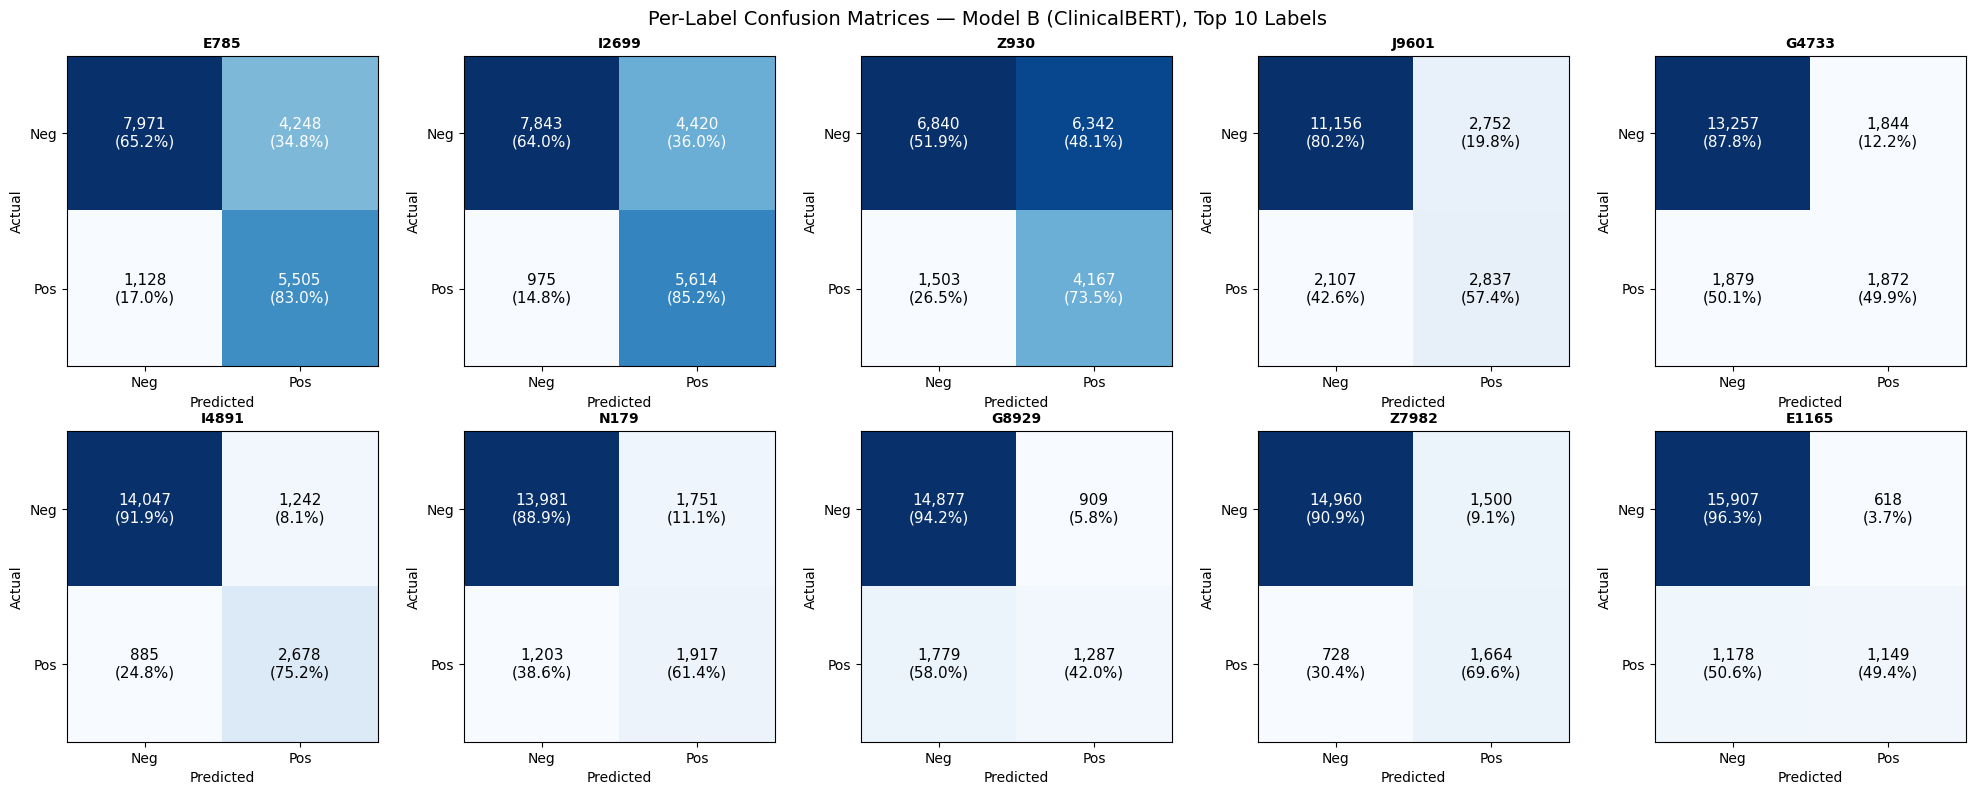


Aggregate Confusion Matrix (all 50 labels):
  TN =    799,414 (84.8%)   FP =     46,079 (4.9%)
  FN =     46,248 (4.9%)   TP =     50,859 (5.4%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, os
from sklearn.metrics import multilabel_confusion_matrix

DATA_DIR  = '../datasets/processed'
MODEL_DIR = '../data/models/model_b'
TOP_N = 10

with open(f'{DATA_DIR}/mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)

Y_test  = np.load(f'{DATA_DIR}/Y_test.npy')

P_test = np.load(f'{MODEL_DIR}/P_test.npy')

with open(f'{MODEL_DIR}/test_results.json') as f:
    threshold = json.load(f)['threshold']
preds_test = (P_test >= threshold).astype(int)

mcm = multilabel_confusion_matrix(Y_test, preds_test)

freq = Y_test.sum(0)
top_idx = np.argsort(freq)[::-1][:TOP_N]

nrows, ncols = 2, TOP_N // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for idx, ax in zip(top_idx, axes.flat):
    cm = mcm[idx]
    ax.imshow(cm, cmap='Blues')
    ax.set_title(vocab[idx], fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm[r, c] > cm.max() / 2 else 'black'
            row_total = cm[r].sum()
            pct = cm[r, c] / row_total * 100 if row_total > 0 else 0
            ax.text(c, r, f'{cm[r, c]:,}\n({pct:.1f}%)', ha='center', va='center', color=color, fontsize=11)

plt.suptitle(f'Per-Label Confusion Matrices — Model B (ClinicalBERT), Top {TOP_N} Labels', fontsize=14)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confusion_matrix_top{TOP_N}.png', dpi=150)
plt.show()

agg = mcm.sum(axis=0)
print(f'\nAggregate Confusion Matrix (all {len(vocab)} labels):')
agg_total = agg.sum()
print(f'  TN = {agg[0,0]:>10,} ({agg[0,0]/agg_total*100:.1f}%)   FP = {agg[0,1]:>10,} ({agg[0,1]/agg_total*100:.1f}%)')
print(f'  FN = {agg[1,0]:>10,} ({agg[1,0]/agg_total*100:.1f}%)   TP = {agg[1,1]:>10,} ({agg[1,1]/agg_total*100:.1f}%)')

## 11. Full 50-Label Confusion Analysis
For each pair of labels (i, j): when label i is truly present in a sample, how often does the model **falsely** predict label j on that same sample? This reveals which ICD codes the model confuses with each other.

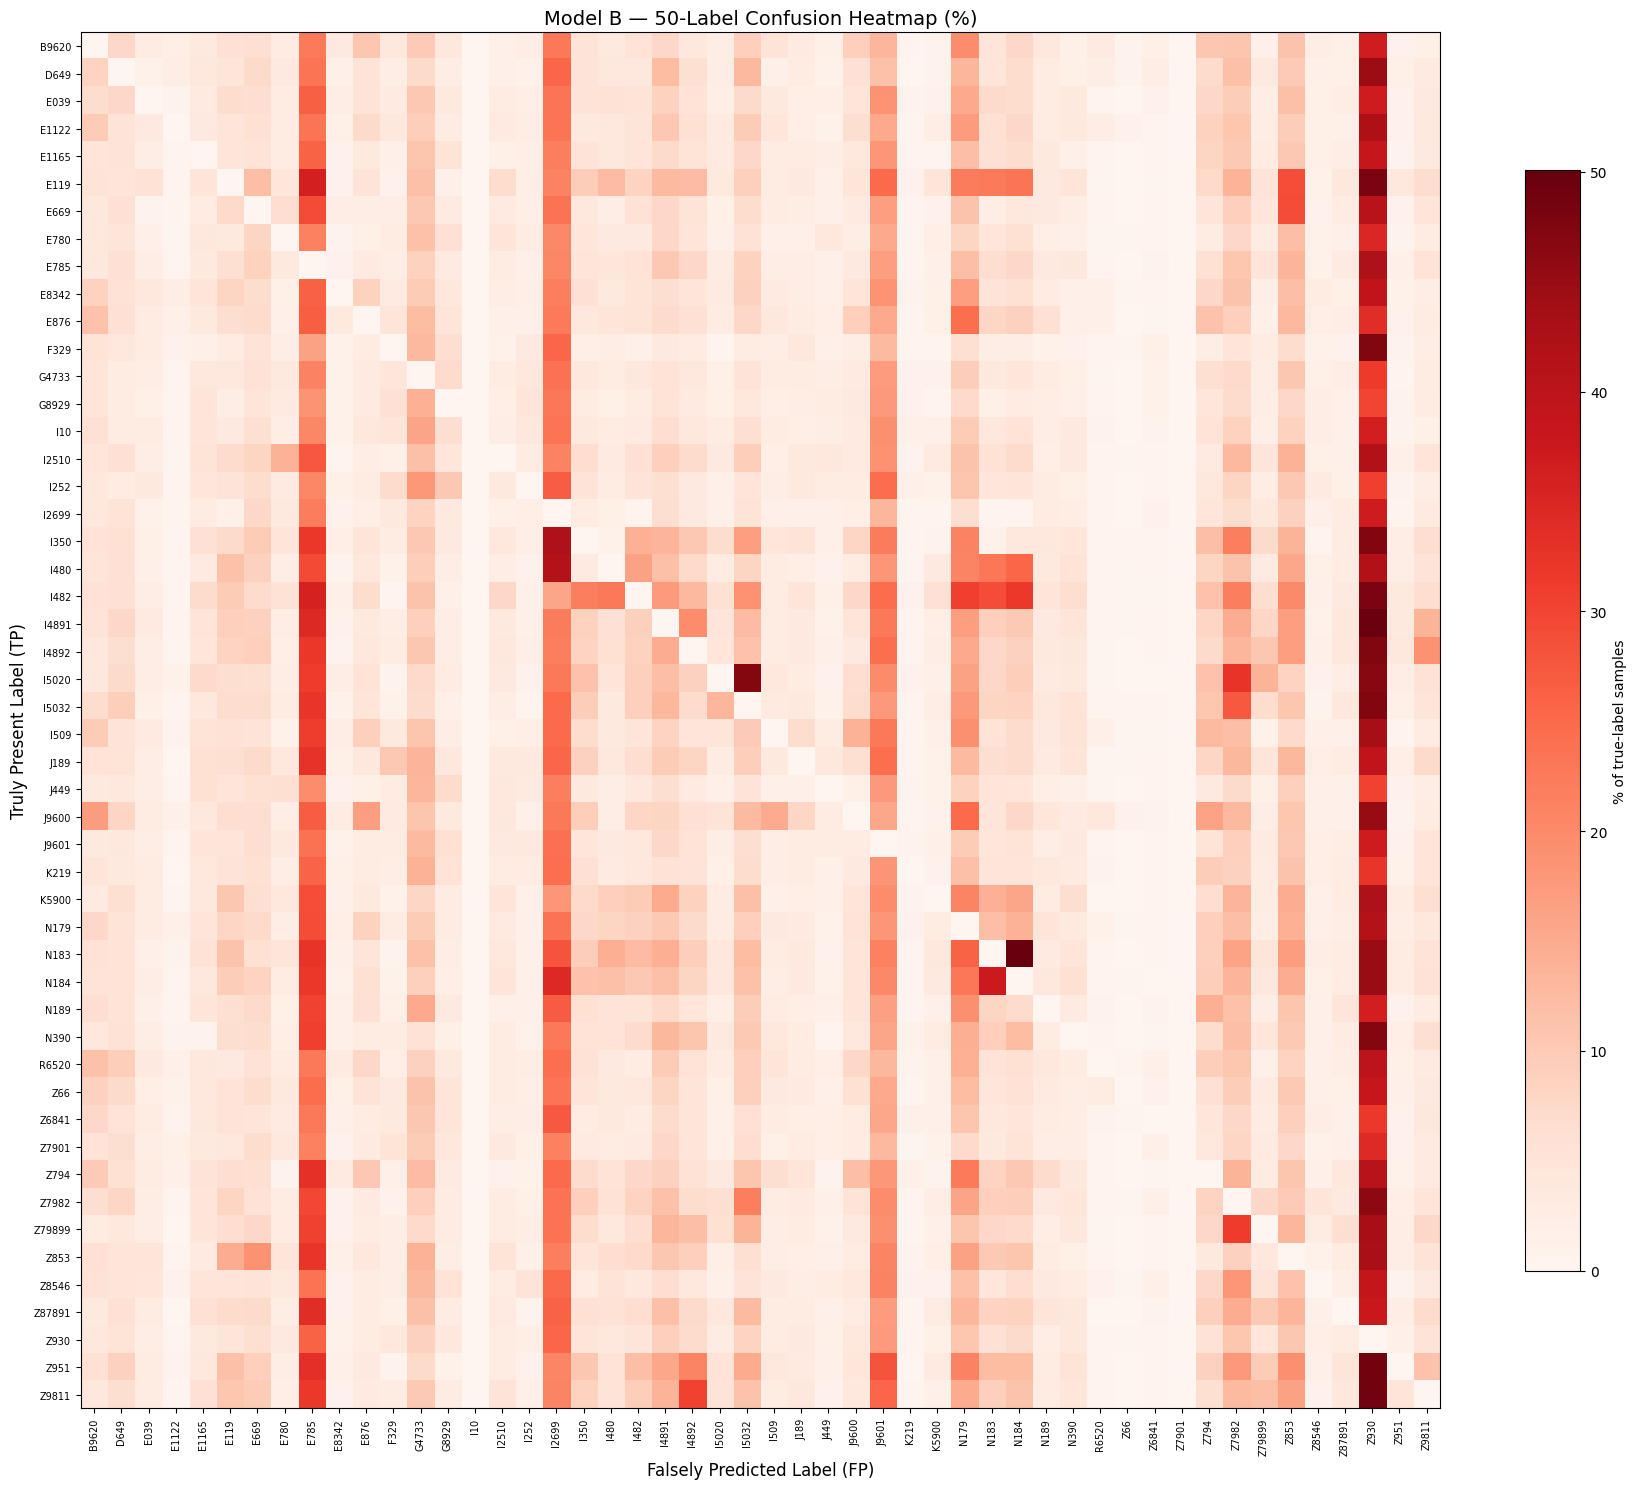


Top 20 most confused label pairs (Model B):
    True Label  →   Falsely Predicted    Count
  --------------------------------------------------
          E785  →                Z930    2,798  (42.2% of E785 samples)
         I2699  →                Z930    2,425  (36.8% of I2699 samples)
         J9601  →                Z930    1,826  (36.9% of J9601 samples)
         I4891  →                Z930    1,767  (49.6% of I4891 samples)
          Z930  →                E785    1,473  (26.0% of Z930 samples)
          Z930  →               I2699    1,453  (25.6% of Z930 samples)
         I2699  →                E785    1,448  (22.0% of I2699 samples)
          E785  →               I2699    1,361  (20.5% of E785 samples)
          N179  →                Z930    1,292  (41.4% of N179 samples)
         I4891  →                E785    1,221  (34.3% of I4891 samples)
         J9601  →               I2699    1,188  (24.0% of J9601 samples)
         J9601  →                E785    1,176  (23.8% of

In [2]:
TOP_PAIRS = 20
n_labels = len(vocab)

fp_mask = (preds_test == 1) & (Y_test == 0)
tp_mask = (Y_test == 1)

label_confusion = tp_mask.astype(int).T @ fp_mask.astype(int)

fig, ax = plt.subplots(figsize=(18, 15))
row_sums = tp_mask.sum(axis=0).reshape(-1, 1)
row_sums = np.where(row_sums == 0, 1, row_sums)
label_confusion_pct = label_confusion / row_sums * 100
im = ax.imshow(label_confusion_pct, cmap='Reds', aspect='auto', interpolation='nearest')
ax.set_xticks(range(n_labels)); ax.set_yticks(range(n_labels))
ax.set_xticklabels(vocab, rotation=90, fontsize=7)
ax.set_yticklabels(vocab, fontsize=7)
ax.set_xlabel('Falsely Predicted Label (FP)', fontsize=12)
ax.set_ylabel('Truly Present Label (TP)', fontsize=12)
ax.set_title(f'Model B — {n_labels}-Label Confusion Heatmap (%)', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label='% of true-label samples')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/label_confusion_{n_labels}x{n_labels}.png', dpi=150)
plt.show()

np.fill_diagonal(label_confusion, 0)
flat_idx = np.argsort(label_confusion.ravel())[::-1]

print(f'\nTop {TOP_PAIRS} most confused label pairs (Model B):')
print(f'  {"True Label":>12s}  →  {"Falsely Predicted":>18s}  {"Count":>7s}')
print('  ' + '-' * 50)
shown = 0
for fi in flat_idx:
    if shown >= TOP_PAIRS:
        break
    i, j = divmod(fi, n_labels)
    count = label_confusion[i, j]
    if count == 0:
        break
    tp_total = tp_mask[:, i].sum()
    pct = count / tp_total * 100 if tp_total > 0 else 0
    print(f'  {vocab[i]:>12s}  →  {vocab[j]:>18s}  {count:>7,}  ({pct:.1f}% of {vocab[i]} samples)')
    shown += 1